Successfully saved to: charts/ycsb_20260313_174941.png


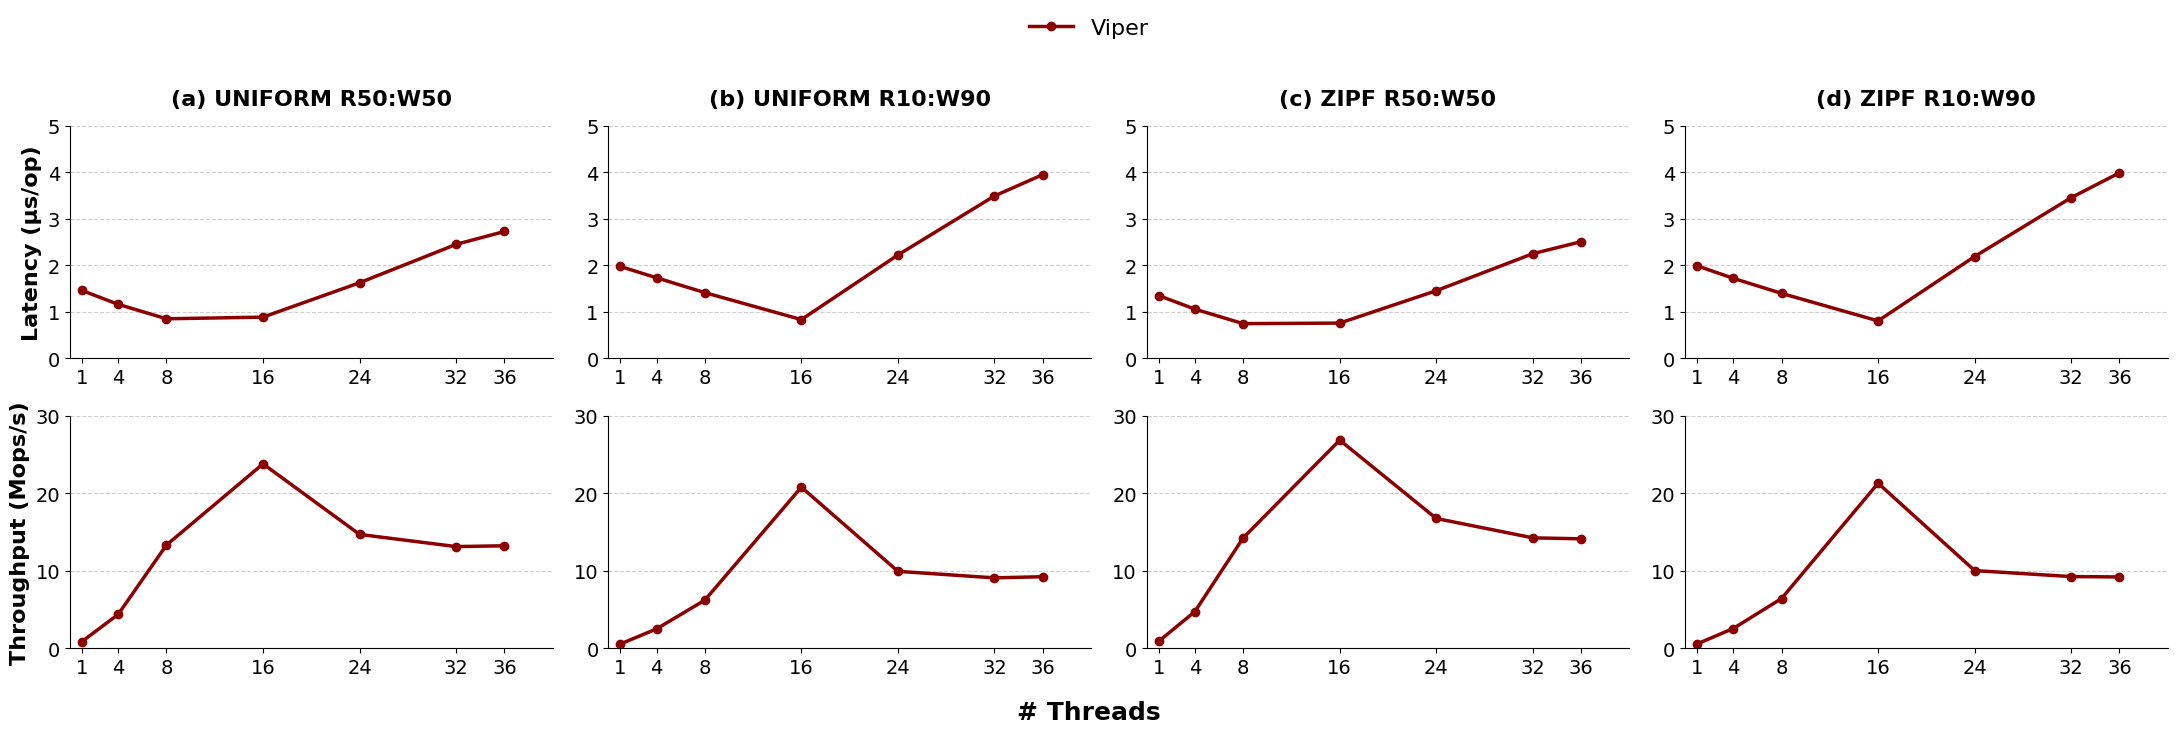

In [1]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import os
import datetime

# 1. 配置路径与全局样式
RESULT_JSON = "/root/NovaKV/results/ycsb/ycsb_2026-03-13-17-30.json"
SAVE_DIR = "charts"
os.makedirs(SAVE_DIR, exist_ok=True) 

plt.rcParams['font.size'] = 14

# 系统定义
VIPER = ("ViperFixture", "Viper")
FIXTURES = [VIPER]
BM_TYPES = ['5050_uniform', '1090_uniform', '5050_zipf', '1090_zipf']

# 2. 读取并解析 JSON
with open(RESULT_JSON, 'r') as f:
    results_raw = json.load(f)
BENCHMARKS = results_raw["benchmarks"]

RUNS = defaultdict(list)
for run in BENCHMARKS:
    name = run['name']
    found_bm = next((bm for bm in BM_TYPES if bm in name), None)
    found_fix = next((f for f in FIXTURES if f[0] in name), None)
    
    if found_bm and found_fix:
        thread_match = re.search(r'threads:(\d+)', name)
        run['threads'] = int(thread_match.group(1)) if thread_match else 1
        RUNS[(found_fix, found_bm)].append(run)

# 排序确保折线顺滑
for key in RUNS:
    RUNS[key].sort(key=lambda x: x['threads'])

# 3. 初始化画布 (2行4列)
fig, axes = plt.subplots(2, 4, figsize=(22, 7))
lat_axes = axes[0]
tp_axes = axes[1]
titles = ["(a) UNIFORM R50:W50", "(b) UNIFORM R10:W90", "(c) ZIPF R50:W50", "(d) ZIPF R10:W90"]

# 4. 绘图循环
for col, bm_type in enumerate(BM_TYPES):
    lt_ax, tp_ax = lat_axes[col], tp_axes[col]
    
    for fixture in FIXTURES:
        data_list = RUNS[(fixture, bm_type)]
        if not data_list:
            continue
            
        tp_data = [r for r in data_list if "_tp" in r['name']]
        lat_data = [r for r in data_list if "_lat" in r['name']]
        
        if tp_data:
            x = [r['threads'] for r in tp_data]
            y = [r['items_per_second'] / 1_000_000 for r in tp_data]
            tp_ax.plot(x, y, marker='o', color='#8b0000', lw=2.5, label=fixture[1])
            
        if lat_data:
            x = [r['threads'] for r in lat_data]
            y = [r['hdr_avg'] / 1000 for r in lat_data] 
            lt_ax.plot(x, y, marker='o', color='#8b0000', lw=2.5)

    # 5. 子图细节规范化
    for ax in [lt_ax, tp_ax]:
        ax.set_xticks([1, 4, 8, 16, 24, 32, 36]) 
        ax.set_xlim(0, 40) 
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    lt_ax.set_title(titles[col], fontsize=16, fontweight='bold', pad=15)
    lt_ax.set_ylim(0, 5)   
    tp_ax.set_ylim(0, 30) 

# 6. 全局修饰
lat_axes[0].set_ylabel("Latency (µs/op)", fontsize=16, fontweight='bold')
tp_axes[0].set_ylabel("Throughput (Mops/s)", fontsize=16, fontweight='bold')
fig.text(0.5, 0.02, "# Threads", ha='center', fontsize=18, fontweight='bold')

handles, labels = tp_axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
                ncol=1, frameon=False, fontsize=16)

# 7. 调整布局并保存 (仅 PNG)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
png_path = os.path.join(SAVE_DIR, f'ycsb_{timestamp}.png')

plt.savefig(png_path, bbox_inches='tight', dpi=300)
print(f"Successfully saved to: {png_path}")
plt.show()